In [2]:
import pandas as pd
import numpy as np

In [3]:
expression_data = pd.read_csv('expression_data.csv')
gene_variances = expression_data.var(axis=1)
top_genes = gene_variances.sort_values(ascending=False).head(10).index
top_variable_expression = expression_data.loc[top_genes]

In [37]:
# Check data dimensions and structure
print("Expression data shape:", expression_data.shape)
print("Top variable expression shape:", top_variable_expression.shape)
print("Number of samples (to be clustered):", top_variable_expression.shape[1])
print("Number of features (genes):", top_variable_expression.shape[0])
print("\nTransposed for clustering:")
print("X shape:", top_variable_expression.T.shape)
print("(rows = samples, columns = features)")

Expression data shape: (43355, 88)
Top variable expression shape: (10, 88)
Number of samples (to be clustered): 88
Number of features (genes): 10

Transposed for clustering:
X shape: (88, 10)
(rows = samples, columns = features)


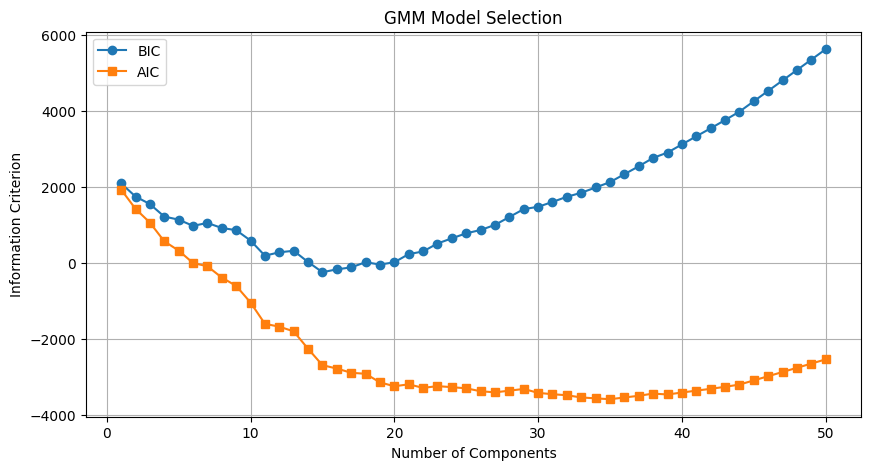

Optimal number of components (by BIC): 15
Optimal number of components (by AIC): 35


In [5]:
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Transpose the data so that samples (columns) are clustered
X = top_variable_expression.T

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Determine optimal number of clusters using BIC
n_components_range = range(1, 51)
bic_scores = []
aic_scores = []

for n_components in n_components_range:
    gmm = GaussianMixture(n_components=n_components, random_state=42)
    gmm.fit(X_scaled)
    bic_scores.append(gmm.bic(X_scaled))
    aic_scores.append(gmm.aic(X_scaled))

# Plot BIC and AIC scores
plt.figure(figsize=(10, 5))
plt.plot(n_components_range, bic_scores, marker='o', label='BIC')
plt.plot(n_components_range, aic_scores, marker='s', label='AIC')
plt.xlabel('Number of Components')
plt.ylabel('Information Criterion')
plt.title('GMM Model Selection')
plt.legend()
plt.grid(True)
plt.show()

# Find optimal number of clusters (minimum BIC or AIC)
optimal_n_components_bic = n_components_range[np.argmin(bic_scores)]
print(f"Optimal number of components (by BIC): {optimal_n_components_bic}")

optimal_n_components_aic = n_components_range[np.argmin(aic_scores)]
print(f"Optimal number of components (by AIC): {optimal_n_components_aic}")

In [39]:
# Find optimal number of clusters for both AIC and BIC
optimal_n_components_bic = n_components_range[np.argmin(bic_scores)]
optimal_n_components_aic = n_components_range[np.argmin(aic_scores)]

print(f"Optimal number of components (by BIC): {optimal_n_components_bic}")
print(f"Optimal number of components (by AIC): {optimal_n_components_aic}")

# Fit GMM model with BIC optimal components
print("\n" + "="*60)
print("CLUSTERING RESULTS USING BIC OPTIMAL COMPONENTS")
print("="*60)
gmm_bic = GaussianMixture(n_components=optimal_n_components_bic, random_state=42)
cluster_labels_bic = gmm_bic.fit_predict(X_scaled)
cluster_probs_bic = gmm_bic.predict_proba(X_scaled)

sample_names = top_variable_expression.columns
clustering_results_bic = pd.DataFrame({
    'Sample': sample_names,
    'Cluster_BIC': cluster_labels_bic
})

for i in range(optimal_n_components_bic):
    clustering_results_bic[f'Prob_Cluster_{i}'] = cluster_probs_bic[:, i]

print("\nClustering Results (BIC):")
print(clustering_results_bic)

print("\nSamples per cluster (BIC):")
print(clustering_results_bic['Cluster_BIC'].value_counts().sort_index())

# Fit GMM model with AIC optimal components
print("\n" + "="*60)
print("CLUSTERING RESULTS USING AIC OPTIMAL COMPONENTS")
print("="*60)
gmm_aic = GaussianMixture(n_components=optimal_n_components_aic, random_state=42)
cluster_labels_aic = gmm_aic.fit_predict(X_scaled)
cluster_probs_aic = gmm_aic.predict_proba(X_scaled)

clustering_results_aic = pd.DataFrame({
    'Sample': sample_names,
    'Cluster_AIC': cluster_labels_aic
})

for i in range(optimal_n_components_aic):
    clustering_results_aic[f'Prob_Cluster_{i}'] = cluster_probs_aic[:, i]

print("\nClustering Results (AIC):")
print(clustering_results_aic)

print("\nSamples per cluster (AIC):")
print(clustering_results_aic['Cluster_AIC'].value_counts().sort_index())

Optimal number of components (by BIC): 15
Optimal number of components (by AIC): 35

CLUSTERING RESULTS USING BIC OPTIMAL COMPONENTS

Clustering Results (BIC):
        Sample  Cluster_BIC  Prob_Cluster_0  Prob_Cluster_1  Prob_Cluster_2  \
0   SRR1785238            4             0.0             0.0             0.0   
1   SRR1785239            4             0.0             0.0             0.0   
2   SRR1785240            8             0.0             0.0             0.0   
3   SRR1785241            8             0.0             0.0             0.0   
4   SRR1785242           14             0.0             0.0             0.0   
..         ...          ...             ...             ...             ...   
83  SRR1785321            6             0.0             0.0             0.0   
84  SRR1785322            9             0.0             0.0             0.0   
85  SRR1785323            9             0.0             0.0             0.0   
86  SRR1785324           13             0.0       

In [6]:
# GMM clustering with top 5000 genes and 2 clusters
print("="*60)
print("GMM CLUSTERING WITH TOP 5000 GENES AND 2 CLUSTERS")
print("="*60)

# Select top 5000 most variable genes
top_5000_genes = gene_variances.sort_values(ascending=False).head(5000).index
top_5000_expression = expression_data.loc[top_5000_genes]

# Transpose so samples are rows and genes are columns
X_5000 = top_5000_expression.T

# Standardize the features
scaler_5000 = StandardScaler()
X_5000_scaled = scaler_5000.fit_transform(X_5000)

# Fit GMM with 2 clusters
gmm_2 = GaussianMixture(n_components=2, random_state=42)
cluster_labels_2 = gmm_2.fit_predict(X_5000_scaled)

# Create results dataframe
sample_names_5000 = top_5000_expression.columns
clustering_results_gmm = pd.DataFrame({
    'Sample': sample_names_5000,
    'Cluster_GMM': cluster_labels_2
})

# Save to CSV file
output_path = '../results/cluster_results_gmm.csv'
clustering_results_gmm.to_csv(output_path, index=False)

print(f"\nClustering results saved to: {output_path}")
print("\nClustering Results:")
print(clustering_results_gmm.head(10))
print(f"\nTotal samples: {len(clustering_results_gmm)}")
print("\nSamples per cluster:")
print(clustering_results_gmm['Cluster_GMM'].value_counts().sort_index())

GMM CLUSTERING WITH TOP 5000 GENES AND 2 CLUSTERS

Clustering results saved to: ../results/cluster_results_gmm.csv

Clustering Results:
       Sample  Cluster_GMM
0  SRR1785238            0
1  SRR1785239            0
2  SRR1785240            0
3  SRR1785241            0
4  SRR1785242            1
5  SRR1785243            1
6  SRR1785244            0
7  SRR1785245            0
8  SRR1785246            1
9  SRR1785247            1

Total samples: 88

Samples per cluster:
Cluster_GMM
0    48
1    40
Name: count, dtype: int64

Clustering results saved to: ../results/cluster_results_gmm.csv

Clustering Results:
       Sample  Cluster_GMM
0  SRR1785238            0
1  SRR1785239            0
2  SRR1785240            0
3  SRR1785241            0
4  SRR1785242            1
5  SRR1785243            1
6  SRR1785244            0
7  SRR1785245            0
8  SRR1785246            1
9  SRR1785247            1

Total samples: 88

Samples per cluster:
Cluster_GMM
0    48
1    40
Name: count, dtype: 

In [42]:
from scipy.stats import chi2_contingency
from itertools import combinations

# Load metadata to get Assignment 1 groups (T0 vs T3)
metadata = pd.read_csv('../data/processed/SRP053101/metadata_SRP053101.tsv', sep='\t')

# Extract timepoint (T0 or T3) from refinebio_title column
metadata['Timepoint'] = metadata['refinebio_title'].str.extract(r'(T\d+)$')

# Create a dictionary mapping sample names to timepoints
sample_to_timepoint = dict(zip(metadata['refinebio_accession_code'], metadata['Timepoint']))

# Configuration
n_genes_list = [10, 100, 1000, 10000]
n_clusters = 2  # Fixed number of clusters to use

# Dictionary to store clustering results for each number of genes
clustering_by_genes = {}

print("="*80)
print("CLUSTERING RESULTS FOR DIFFERENT NUMBERS OF GENES")
print("="*80)

# Run GMM clustering for each number of genes
for n_genes in n_genes_list:
    # Select top n most variable genes
    top_genes_subset = gene_variances.sort_values(ascending=False).head(n_genes).index
    top_variable_subset = expression_data.loc[top_genes_subset]
    
    # Transpose and scale
    X_subset = top_variable_subset.T
    scaler_subset = StandardScaler()
    X_scaled_subset = scaler_subset.fit_transform(X_subset)
    
    # Fit GMM
    gmm_subset = GaussianMixture(n_components=n_clusters, random_state=42)
    cluster_labels_subset = gmm_subset.fit_predict(X_scaled_subset)
    
    # Store results
    clustering_by_genes[n_genes] = cluster_labels_subset
    
    print(f"\n{n_genes} genes: {len(set(cluster_labels_subset))} clusters formed")

# Get Assignment 1 group labels (T0/T3) for samples (in the same order as clustering)
sample_names = top_variable_subset.columns
assignment1_labels = [sample_to_timepoint.get(sample, 'Unknown') for sample in sample_names]

print(f"\nAssignment 1 groups (T0/T3): {len([x for x in assignment1_labels if x == 'T0'])} T0 samples, {len([x for x in assignment1_labels if x == 'T3'])} T3 samples")

# Perform chi-squared tests
chi_squared_results = []

# 1. Compare clustering results between different numbers of genes
print("\n" + "="*80)
print("CHI-SQUARED TESTS: COMPARING CLUSTERING WITH DIFFERENT NUMBERS OF GENES")
print("="*80)

for (n_genes_1, n_genes_2) in combinations(n_genes_list, 2):
    labels_1 = clustering_by_genes[n_genes_1]
    labels_2 = clustering_by_genes[n_genes_2]
    
    # Create contingency table
    contingency_table = pd.crosstab(labels_1, labels_2)
    
    # Perform chi-squared test
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    
    chi_squared_results.append({
        'Comparison': f'{n_genes_1} vs {n_genes_2} genes',
        'Type': 'Gene count comparison',
        'Chi-squared': chi2,
        'p-value': p_value,
        'Adjusted p-value': None,  # No adjustment for gene count comparisons
        'Degrees of Freedom': dof,
        'Significant (α=0.05)': 'Yes' if p_value < 0.05 else 'No'
    })

# 2. Compare each clustering result with Assignment 1 groups (T0/T3)
print("\n" + "="*80)
print("CHI-SQUARED TESTS: COMPARING CLUSTERING WITH TIMEPOINTS (T0 vs T3)")
print("="*80)

# Store p-values for multiple testing correction
timepoint_pvalues = []

for n_genes in n_genes_list:
    cluster_labels = clustering_by_genes[n_genes]
    
    # Create contingency table
    contingency_table = pd.crosstab(cluster_labels, assignment1_labels)
    print(f"\nContingency Table for {n_genes} genes vs Timepoints:")
    print(contingency_table)
    
    # Perform chi-squared test
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    timepoint_pvalues.append(p_value)
    
    chi_squared_results.append({
        'Comparison': f'{n_genes} genes vs Timepoints',
        'Type': 'Clustering vs T0/T3',
        'Chi-squared': chi2,
        'p-value': p_value,
        'Adjusted p-value': None,  # Will be filled in next step
        'Degrees of Freedom': dof,
        'Significant (α=0.05)': None  # Will be determined after adjustment
    })

# Apply Bonferroni correction to timepoint comparisons
n_timepoint_tests = len(timepoint_pvalues)
bonferroni_adjusted = [min(p * n_timepoint_tests, 1.0) for p in timepoint_pvalues]

# Update the results with adjusted p-values
timepoint_idx = 0
for i, result in enumerate(chi_squared_results):
    if result['Type'] == 'Clustering vs T0/T3':
        result['Adjusted p-value'] = bonferroni_adjusted[timepoint_idx]
        result['Significant (α=0.05)'] = 'Yes' if bonferroni_adjusted[timepoint_idx] < 0.05 else 'No'
        timepoint_idx += 1

# Display comprehensive summary table
print("\n" + "="*80)
print("COMPREHENSIVE CHI-SQUARED TEST RESULTS")
print("="*80)
chi_squared_df = pd.DataFrame(chi_squared_results)
print(chi_squared_df.to_string(index=False))

# Separate tables for easier reading
print("\n" + "="*80)
print("GENE COUNT COMPARISONS ONLY")
print("="*80)
gene_comparisons = chi_squared_df[chi_squared_df['Type'] == 'Gene count comparison']
print(gene_comparisons[['Comparison', 'Chi-squared', 'p-value', 'Degrees of Freedom', 'Significant (α=0.05)']].to_string(index=False))

print("\n" + "="*80)
print("TIMEPOINT (T0 vs T3) COMPARISONS ONLY")
print(f"(Bonferroni correction applied: {n_timepoint_tests} tests)")
print("="*80)
timepoint_comparisons = chi_squared_df[chi_squared_df['Type'] == 'Clustering vs T0/T3']
print(timepoint_comparisons.to_string(index=False))

CLUSTERING RESULTS FOR DIFFERENT NUMBERS OF GENES

10 genes: 2 clusters formed

100 genes: 2 clusters formed

1000 genes: 2 clusters formed

10000 genes: 2 clusters formed

Assignment 1 groups (T0/T3): 44 T0 samples, 44 T3 samples

CHI-SQUARED TESTS: COMPARING CLUSTERING WITH DIFFERENT NUMBERS OF GENES

CHI-SQUARED TESTS: COMPARING CLUSTERING WITH TIMEPOINTS (T0 vs T3)

Contingency Table for 10 genes vs Timepoints:
col_0  T0  T3
row_0        
0      16   4
1      28  40

Contingency Table for 100 genes vs Timepoints:
col_0  T0  T3
row_0        
0      14  14
1      30  30

Contingency Table for 1000 genes vs Timepoints:
col_0  T0  T3
row_0        
0      10  28
1      34  16

Contingency Table for 10000 genes vs Timepoints:
col_0  T0  T3
row_0        
0      16  20
1      28  24

COMPREHENSIVE CHI-SQUARED TEST RESULTS
               Comparison                  Type  Chi-squared  p-value  Adjusted p-value  Degrees of Freedom Significant (α=0.05)
          10 vs 100 genes Gene count comp